In [1]:
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.io.matlab import mat_struct
from scipy.ndimage import gaussian_filter1d

DATA_ROOT = Path("/home/ganchao/isilon/AllStaff/auditory/m96z")

# Start with U331 only. Do not combine experiments yet.
FOCUS_EXPERIMENTS = ["U331"]

VOC_LIST_PATH = DATA_ROOT / "M96z_voclist.txt"

OUT_ROOT = Path("/home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Use only clean call types for classification.
KEEP_CALL_TYPES = ["phee", "twitter", "trill", "trill_phee"]

SMOOTH_SIGMA_BINS = 5.0
TEST_FRAC = 0.2
SEED = 123

print("DATA_ROOT:", DATA_ROOT)
print("VOC_LIST_PATH:", VOC_LIST_PATH, VOC_LIST_PATH.exists())
print("OUT_ROOT:", OUT_ROOT)
print("KEEP_CALL_TYPES:", KEEP_CALL_TYPES)

DATA_ROOT: /home/ganchao/isilon/AllStaff/auditory/m96z
VOC_LIST_PATH: /home/ganchao/isilon/AllStaff/auditory/m96z/M96z_voclist.txt True
OUT_ROOT: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype
KEEP_CALL_TYPES: ['phee', 'twitter', 'trill', 'trill_phee']


In [2]:
def normalize_call_type(s):
    s = s.strip().lower()
    s = s.replace("-", "_")
    s = s.replace(" ", "_")
    return s

def normalize_stim_name(s):
    s = str(s).strip()
    s = s.replace("\\", "/")
    return Path(s).name

def parse_voclist(path, keep_call_types=None):
    voc_to_call = {}
    call_to_vocs = {}
    ordered_vocs = []

    if keep_call_types is not None:
        keep_call_types = set(keep_call_types)

    current_call = None

    with open(path, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if len(line) == 0:
                continue

            m = re.match(r"^(.+?)\s+List\s*:", line, flags=re.IGNORECASE)
            if m is not None:
                current_call = normalize_call_type(m.group(1))
                continue

            if current_call is None:
                continue

            if keep_call_types is not None and current_call not in keep_call_types:
                continue

            if ".txt" not in line:
                continue

            stim = normalize_stim_name(line.split()[0])

            voc_to_call[stim] = current_call
            call_to_vocs.setdefault(current_call, []).append(stim)
            ordered_vocs.append(stim)

    return voc_to_call, call_to_vocs, ordered_vocs

voc_to_call, call_to_vocs, ordered_vocs = parse_voclist(
    VOC_LIST_PATH,
    keep_call_types=KEEP_CALL_TYPES,
)

print("call types:")
for k in KEEP_CALL_TYPES:
    print(f"{k:12s}", len(call_to_vocs.get(k, [])))

print("\nfirst few mappings:")
for stim in ordered_vocs[:10]:
    print(stim, "->", voc_to_call[stim])

assert set(call_to_vocs.keys()) == set(KEEP_CALL_TYPES)

call types:
phee         10
twitter      10
trill        10
trill_phee   10

first few mappings:
ant_m96z_S14_000001.txt -> phee
ant_m96z_S15_000015.txt -> phee
ant_m96z_S18_000002.txt -> phee
ant_m96z_S25_000006.txt -> phee
ant_m96z_S13_000031.txt -> phee
ant_m96z_S15_000006.txt -> phee
ant_m96z_S15_000021.txt -> phee
ant_m96z_S18_000006.txt -> phee
ant_m96z_S13_000010.txt -> phee
ant_m96z_S23_000015.txt -> phee


In [3]:
mua_files = sorted(DATA_ROOT.glob("m96z_*_playback_mua.mat"))

if FOCUS_EXPERIMENTS is not None:
    mua_files = [
        p for p in mua_files
        if any(exp in p.name for exp in FOCUS_EXPERIMENTS)
    ]

print("MUA files:")
for p in mua_files:
    print(" ", p.name)

assert len(mua_files) > 0, "No MUA files found."

MUA files:
  m96z_U331_playback_mua.mat


In [4]:
def load_mat_file(path):
    return loadmat(path, squeeze_me=True, struct_as_record=False)

def iter_nested(obj, path="root", max_depth=10, depth=0):
    if depth > max_depth:
        return

    yield path, obj

    if isinstance(obj, dict):
        for k, v in obj.items():
            if not str(k).startswith("__"):
                yield from iter_nested(v, f"{path}.{k}", max_depth, depth + 1)

    elif isinstance(obj, mat_struct):
        for field in obj._fieldnames:
            yield from iter_nested(
                getattr(obj, field),
                f"{path}.{field}",
                max_depth,
                depth + 1,
            )

    elif isinstance(obj, np.ndarray):
        if obj.dtype == object:
            for i, x in enumerate(obj.ravel()):
                yield from iter_nested(
                    x,
                    f"{path}[{i}]",
                    max_depth,
                    depth + 1,
                )

def collect_strings(obj):
    out = []

    for _, x in iter_nested(obj):
        if isinstance(x, str):
            out.append(x)

        elif isinstance(x, bytes):
            out.append(x.decode(errors="ignore"))

        elif isinstance(x, np.ndarray) and x.dtype.kind in ["U", "S"]:
            out.extend([str(v) for v in x.ravel()])

    return out

def find_numeric_arrays(obj, min_size=2):
    out = []

    for path, x in iter_nested(obj):
        if isinstance(x, np.ndarray) and np.issubdtype(x.dtype, np.number):
            x = np.asarray(x)
            if x.size >= min_size:
                out.append((path, x))

    return out

def numeric_candidates(mat):
    out = []

    for path, x in find_numeric_arrays(mat):
        out.append((path, x.shape, x.dtype, x.size))

    return sorted(out, key=lambda z: z[-1], reverse=True)

def string_candidates(mat):
    out = []

    for path, x in iter_nested(mat):
        ss = collect_strings(x)
        ss = [s for s in ss if ".txt" in str(s)]

        if len(ss) > 0:
            out.append((path, len(ss), ss[:5]))

    return out

In [5]:
mat0 = load_mat_file(mua_files[0])

print("file:", mua_files[0].name)

print("\nTop-level keys:")
print([k for k in mat0.keys() if not k.startswith("__")])

print("\nRecursive numeric candidates:")
for item in numeric_candidates(mat0)[:30]:
    print(item)

print("\nRecursive string candidates containing .txt:")
for item in string_candidates(mat0)[:20]:
    print(item)

file: m96z_U331_playback_mua.mat

Top-level keys:
['pbdata']

Recursive numeric candidates:
('root.pbdata.phee.mua[0][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[1][9]', (5, 5876), dtype('uint8'), 29380)
('root.pbdata.phee.mua[2][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[3][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[4][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[5][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[6][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[7][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[8][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[9][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[10][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[11][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[12][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.mua[13][9]', (5, 5876), dtype('<f8'), 29380)
('root.pbdata.phee.m

In [6]:
# Force block-wise UMA/MUA loading from pbdata.<call_type>.mua.
# Structure:
#   pbdata.<call>.mua[unit][stim] -> repeat x time
#
# One sample = one repeat of one stimulus:
#   X sample shape = time x unit

PB_CALL_FIELD_TO_CLASS = {
    "phee": "phee",
    "twitter": "twitter",
    "trill": "trill",
    "trilphee": "trill_phee",
}

def get_struct_field(obj, field):
    if isinstance(obj, dict):
        return obj[field]
    return getattr(obj, field)

def has_struct_field(obj, field):
    if isinstance(obj, dict):
        return field in obj
    return hasattr(obj, field)

def get_vocfiles(section):
    if has_struct_field(section, "vocfiles"):
        strings = collect_strings(get_struct_field(section, "vocfiles"))
    else:
        strings = collect_strings(section)

    vocfiles = [
        normalize_stim_name(s)
        for s in strings
        if ".txt" in str(s)
    ]

    return vocfiles

def orient_repeat_time(A):
    A = np.asarray(A)
    A = np.squeeze(A)

    if A.ndim == 1:
        A = A[None, :]

    assert A.ndim == 2, f"Expected repeat x time or time x repeat, got {A.shape}"

    # Repeats should be the shorter axis, time should be the longer axis.
    if A.shape[0] > A.shape[1]:
        A = A.T

    A = np.asarray(A, dtype=np.float32)
    A = np.nan_to_num(A)

    return A

def collect_mua_leaves(mua_obj):
    leaves = []

    for path, arr in find_numeric_arrays(mua_obj, min_size=100):
        arr = np.asarray(arr)
        arr_s = np.squeeze(arr)

        if arr_s.ndim != 2:
            continue

        inds = [int(x) for x in re.findall(r"\[(\d+)\]", path)]

        if len(inds) < 2:
            continue

        leaves.append({
            "path": path,
            "inds": inds,
            "raw_shape": arr_s.shape,
            "arr": arr_s,
        })

    assert len(leaves) > 0, "No 2D UMA/MUA leaves found."

    return leaves

def infer_stim_unit_positions(leaves, n_stim):
    max_len = max(len(x["inds"]) for x in leaves)

    values_by_pos = {}

    for pos in range(max_len):
        vals = []

        for leaf in leaves:
            if len(leaf["inds"]) > pos:
                vals.append(leaf["inds"][pos])

        values_by_pos[pos] = sorted(set(vals))

    stim_candidates = []

    for pos, vals in values_by_pos.items():
        if vals == list(range(n_stim)):
            stim_candidates.append(pos)

    assert len(stim_candidates) > 0, (
        "Could not infer stimulus index position. "
        f"n_stim={n_stim}, index values={values_by_pos}"
    )

    stim_pos = stim_candidates[-1]

    unit_candidates = [
        pos for pos in values_by_pos
        if pos != stim_pos
    ]

    assert len(unit_candidates) > 0, "Could not infer unit index position."

    unit_pos = max(
        unit_candidates,
        key=lambda pos: len(values_by_pos[pos])
    )

    return stim_pos, unit_pos, values_by_pos

def mua_block_to_samples(mua_obj, vocfiles, call_type, source_file):
    n_stim = len(vocfiles)
    assert n_stim > 0, "No vocfiles found."

    leaves = collect_mua_leaves(mua_obj)
    stim_pos, unit_pos, values_by_pos = infer_stim_unit_positions(leaves, n_stim)

    leaf_dict = {}
    raw_shape_dict = {}
    path_dict = {}

    for leaf in leaves:
        inds = leaf["inds"]

        if len(inds) <= max(stim_pos, unit_pos):
            continue

        stim_idx = inds[stim_pos]
        unit_idx = inds[unit_pos]

        if stim_idx < 0 or stim_idx >= n_stim:
            continue

        x = orient_repeat_time(leaf["arr"])

        leaf_dict[(stim_idx, unit_idx)] = x
        raw_shape_dict[(stim_idx, unit_idx)] = leaf["raw_shape"]
        path_dict[(stim_idx, unit_idx)] = leaf["path"]

    unit_ids = sorted(set(k[1] for k in leaf_dict.keys()))
    stim_ids = list(range(n_stim))

    assert len(unit_ids) > 0, "No units found."

    missing = [
        (s, u)
        for s in stim_ids
        for u in unit_ids
        if (s, u) not in leaf_dict
    ]

    assert len(missing) == 0, f"Missing stim/unit MUA entries, first few: {missing[:10]}"

    # Critical fix:
    # Different stimuli can have different time lengths.
    # Use one common time length before concatenating samples.
    global_T = min(
        leaf_dict[(s, u)].shape[1]
        for s in stim_ids
        for u in unit_ids
    )

    X_parts = []
    rows = []

    for stim_idx, stim_name in enumerate(vocfiles):
        unit_arrays = [leaf_dict[(stim_idx, u)] for u in unit_ids]

        n_reps = min(a.shape[0] for a in unit_arrays)

        X_stim = np.stack(
            [a[:n_reps, :global_T] for a in unit_arrays],
            axis=-1,
        )

        X_parts.append(X_stim)

        example_key = (stim_idx, unit_ids[0])

        for rep_idx in range(n_reps):
            rows.append({
                "source_file": source_file,
                "call_type": call_type,
                "stim_idx": stim_idx,
                "stim_name": stim_name,
                "rep_idx": rep_idx,
                "n_units": len(unit_ids),
                "n_time": global_T,
                "chosen_mua_path": path_dict[example_key],
                "raw_mua_shape": str(raw_shape_dict[example_key]),
                "oriented_shape": str((global_T, len(unit_ids))),
            })

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    table = pd.DataFrame(rows)

    assert X.shape[0] == len(table)
    assert X.shape[1] == global_T
    assert X.shape[2] == len(unit_ids)

    return X, table

def load_uma_from_pbdata(mat, source_file):
    assert "pbdata" in mat, "No pbdata found."

    pbdata = mat["pbdata"]

    Xs = []
    tabs = []

    for field_name, call_type in PB_CALL_FIELD_TO_CLASS.items():
        if call_type not in KEEP_CALL_TYPES:
            continue

        assert has_struct_field(pbdata, field_name), f"pbdata has no field {field_name}"

        section = get_struct_field(pbdata, field_name)
        vocfiles = get_vocfiles(section)

        keep = [
            i for i, stim in enumerate(vocfiles)
            if stim in voc_to_call and voc_to_call[stim] == call_type
        ]

        assert len(keep) > 0, f"No matched vocfiles for {call_type}"

        vocfiles_keep = [vocfiles[i] for i in keep]

        mua_obj = get_struct_field(section, "mua")

        X_call, tab_call = mua_block_to_samples(
            mua_obj=mua_obj,
            vocfiles=vocfiles,
            call_type=call_type,
            source_file=source_file,
        )

        keep_stim_set = set(vocfiles_keep)
        keep_sample = tab_call["stim_name"].isin(keep_stim_set).to_numpy()

        X_call = X_call[keep_sample]
        tab_call = tab_call.loc[keep_sample].reset_index(drop=True)

        Xs.append(X_call)
        tabs.append(tab_call)

        print(f"\nLoaded call block: {field_name} -> {call_type}")
        print("  vocfiles:", len(vocfiles))
        print("  kept stimuli:", len(vocfiles_keep))
        print("  X_call:", X_call.shape)
        print("  samples per stimulus:")
        print(tab_call["stim_name"].value_counts().sort_index().head())

    unit_dims = sorted(set(x.shape[2] for x in Xs))
    assert len(unit_dims) == 1, f"Different unit dimensions across calls: {unit_dims}"

    min_T = min(x.shape[1] for x in Xs)

    if len(set(x.shape[1] for x in Xs)) > 1:
        print("Call blocks have different time lengths. Trimming all to:", min_T)

    X = np.concatenate([x[:, :min_T, :] for x in Xs], axis=0).astype(np.float32)
    table = pd.concat(tabs, ignore_index=True)

    table["oriented_shape"] = str((min_T, X.shape[2]))

    assert X.shape[0] == len(table)
    assert X.ndim == 3

    return X, table

In [7]:
def experiment_id_from_path(path):
    m = re.search(r"m96z_(U\d+)_playback_mua\.mat", path.name)

    if m is None:
        return path.stem

    return m.group(1)

def load_one_mua_file(path):
    mat = load_mat_file(path)

    X, trial_table = load_uma_from_pbdata(
        mat=mat,
        source_file=path.name,
    )

    exp_id = experiment_id_from_path(path)
    trial_table["exp_id"] = exp_id

    call_labels = trial_table["call_type"].to_numpy(dtype=object)
    stim_names = trial_table["stim_name"].to_numpy(dtype=object)
    exp_ids = trial_table["exp_id"].to_numpy(dtype=object)

    print("\nLoaded full file:", path.name)
    print("  X:", X.shape)
    print("  samples:", len(trial_table))
    print("  units:", X.shape[2])
    print("  time bins:", X.shape[1])

    print("\n  counts:")
    for ct in KEEP_CALL_TYPES:
        print(f"  {ct:12s}", np.sum(call_labels == ct))

    return X, call_labels, stim_names, exp_ids, trial_table

In [8]:
Xs = []
ys_call = []
stim_all = []
exp_all = []
trial_tables = []

for path in mua_files:
    X_i, y_i, stim_i, exp_i, tab_i = load_one_mua_file(path)

    Xs.append(X_i)
    ys_call.append(y_i)
    stim_all.append(stim_i)
    exp_all.append(exp_i)
    trial_tables.append(tab_i)

unit_dims = sorted(set(x.shape[2] for x in Xs))
assert len(unit_dims) == 1, f"Different unit dimensions across files: {unit_dims}"

min_T = min(x.shape[1] for x in Xs)

if len(set(x.shape[1] for x in Xs)) > 1:
    print("Files have different time lengths. Trimming all to:", min_T)

X_raw = np.concatenate([x[:, :min_T, :] for x in Xs], axis=0)
call_labels = np.concatenate(ys_call, axis=0)
stim_names = np.concatenate(stim_all, axis=0)
exp_ids = np.concatenate(exp_all, axis=0)
trial_table = pd.concat(trial_tables, ignore_index=True)

CLASS_NAMES = KEEP_CALL_TYPES.copy()
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
y = np.asarray([CLASS_TO_ID[c] for c in call_labels], dtype=np.int64)

print("\nFinal raw X:", X_raw.shape)
print("Final y:", y.shape)
print("CLASS_NAMES:", CLASS_NAMES)

print("\nCounts:")
for k, name in enumerate(CLASS_NAMES):
    print(f"{name:12s}", np.sum(y == k))

print("\nStimulus counts:")
print(trial_table.groupby(["call_type", "stim_name"]).size())

assert X_raw.shape[0] == len(y) == len(stim_names) == len(exp_ids) == len(trial_table)
assert X_raw.ndim == 3
assert X_raw.shape[0] > 1
assert X_raw.shape[2] > 1
assert set(call_labels).issubset(set(KEEP_CALL_TYPES))
assert "other" not in set(call_labels)

# For U331, this should usually be 4 call types x 10 stimuli x 5 repeats = 200.
print("\nExpected sanity:")
print("  samples should be near 200 for U331")
print("  units should be near 30 for U331")


Loaded call block: phee -> phee
  vocfiles: 10
  kept stimuli: 10
  X_call: (50, 2515, 32)
  samples per stimulus:
stim_name
ant_m96z_S13_000010.txt    5
ant_m96z_S13_000031.txt    5
ant_m96z_S14_000001.txt    5
ant_m96z_S15_000006.txt    5
ant_m96z_S15_000015.txt    5
Name: count, dtype: int64

Loaded call block: twitter -> twitter
  vocfiles: 10
  kept stimuli: 10
  X_call: (50, 2032, 32)
  samples per stimulus:
stim_name
voc_m96z_S12_000013.txt    5
voc_m96z_S1_000111.txt     5
voc_m96z_S1_000215.txt     5
voc_m96z_S1_000219.txt     5
voc_m96z_S2_000138.txt     5
Name: count, dtype: int64

Loaded call block: trill -> trill
  vocfiles: 10
  kept stimuli: 10
  X_call: (50, 1441, 32)
  samples per stimulus:
stim_name
voc_m96z_S1_000072.txt    5
voc_m96z_S1_000109.txt    5
voc_m96z_S2_000086.txt    5
voc_m96z_S3_000094.txt    5
voc_m96z_S3_000204.txt    5
Name: count, dtype: int64

Loaded call block: trilphee -> trill_phee
  vocfiles: 10
  kept stimuli: 10
  X_call: (50, 2406, 32)
  sa

In [9]:
# Diagnostic 1: check whether data loading is structurally correct

display(trial_table.head(20))

print("Final X shape:", X_raw.shape)
print("n samples:", X_raw.shape[0])
print("n time bins:", X_raw.shape[1])
print("n units:", X_raw.shape[2])

print("\nCounts by call type:")
display(trial_table["call_type"].value_counts().reindex(CLASS_NAMES))

print("\nStimuli per call type:")
display(trial_table.groupby("call_type")["stim_name"].nunique().reindex(CLASS_NAMES))

print("\nRepeats per stimulus:")
rep_counts = trial_table.groupby(["call_type", "stim_name"]).size()
display(rep_counts)

print("\nUnique chosen MUA paths, example paths:")
display(trial_table["chosen_mua_path"].drop_duplicates().head(20))

print("\nUnique raw MUA shapes:")
display(trial_table["raw_mua_shape"].value_counts())

print("\nUnique oriented shapes:")
display(trial_table["oriented_shape"].value_counts())

assert trial_table["call_type"].nunique() == len(CLASS_NAMES)
assert all(trial_table.groupby("call_type")["stim_name"].nunique().reindex(CLASS_NAMES) == 10)
assert rep_counts.nunique() == 1
assert rep_counts.iloc[0] >= 2
assert X_raw.shape[0] == len(trial_table)
assert X_raw.shape[2] >= 5

,source_file,call_type,stim_idx,stim_name,rep_idx,n_units,n_time,chosen_mua_path,raw_mua_shape,oriented_shape,exp_id
0,m96z_U331_playback_mua.mat,phee,0,ant_m96z_S14_000001.txt,0,32,2515,root[0][0],"(5, 3426)","(1441, 32)",U331
1,m96z_U331_playback_mua.mat,phee,0,ant_m96z_S14_000001.txt,1,32,2515,root[0][0],"(5, 3426)","(1441, 32)",U331
2,m96z_U331_playback_mua.mat,phee,0,ant_m96z_S14_000001.txt,2,32,2515,root[0][0],"(5, 3426)","(1441, 32)",U331
3,m96z_U331_playback_mua.mat,phee,0,ant_m96z_S14_000001.txt,3,32,2515,root[0][0],"(5, 3426)","(1441, 32)",U331
4,m96z_U331_playback_mua.mat,phee,0,ant_m96z_S14_000001.txt,4,32,2515,root[0][0],"(5, 3426)","(1441, 32)",U331
5,m96z_U331_playback_mua.mat,phee,1,ant_m96z_S15_000015.txt,0,32,2515,root[0][1],"(5, 3333)","(1441, 32)",U331
6,m96z_U331_playback_mua.mat,phee,1,ant_m96z_S15_000015.txt,1,32,2515,root[0][1],"(5, 3333)","(1441, 32)",U331
7,m96z_U331_playback_mua.mat,phee,1,ant_m96z_S15_000015.txt,2,32,2515,root[0][1],"(5, 3333)","(1441, 32)",U331
8,m96z_U331_playback_mua.mat,phee,1,ant_m96z_S15_000015.txt,3,32,2515,root[0][1],"(5, 3333)","(1441, 32)",U331
9,m96z_U331_playback_mua.mat,phee,1,ant_m96z_S15_000015.txt,4,32,2515,root[0][1],"(5, 3333)","(1441, 32)",U331


Final X shape: (200, 1441, 32)
n samples: 200
n time bins: 1441
n units: 32

Counts by call type:


call_type
phee          50
twitter       50
trill         50
trill_phee    50
Name: count, dtype: int64


Stimuli per call type:


call_type
phee          10
twitter       10
trill         10
trill_phee    10
Name: stim_name, dtype: int64

...

0     root[0][0]
5     root[0][1]
10    root[0][2]
15    root[0][3]
20    root[0][4]
25    root[0][5]
30    root[0][6]
35    root[0][7]
40    root[0][8]
45    root[0][9]
Name: chosen_mua_path, dtype: object


Unique raw MUA shapes:


raw_mua_shape
(5, 1636)    10
(5, 3333)    10
(5, 3426)     5
(5, 1910)     5
(5, 1954)     5
(5, 1612)     5
(5, 2076)     5
(5, 1441)     5
(5, 1697)     5
(5, 1581)     5
(5, 2830)     5
(5, 3191)     5
(5, 3019)     5
(5, 3053)     5
(5, 2648)     5
(5, 2406)     5
(5, 3876)     5
(5, 3321)     5
(5, 1539)     5
(5, 2388)     5
(5, 2442)     5
(5, 2518)     5
(5, 3853)     5
(5, 2515)     5
(5, 4371)     5
(5, 3724)     5
(5, 4090)     5
(5, 4859)     5
(5, 5528)     5
(5, 5876)     5
(5, 2159)     5
(5, 2630)     5
(5, 2853)     5
(5, 2909)     5
(5, 2032)     5
(5, 2034)     5
(5, 2718)     5
(5, 2808)     5
Name: count, dtype: int64


Unique oriented shapes:


oriented_shape
(1441, 32)    200
Name: count, dtype: int64

In [10]:
def make_group_split(y, groups, test_frac=0.2, seed=123):
    rng = np.random.default_rng(seed)

    groups = np.asarray(groups)
    y = np.asarray(y)

    test_mask = np.zeros(len(y), dtype=bool)

    for k in sorted(set(y)):
        idx_k = np.where(y == k)[0]
        groups_k = np.unique(groups[idx_k])

        rng.shuffle(groups_k)

        n_test_groups = max(1, int(round(test_frac * len(groups_k))))
        test_groups = set(groups_k[:n_test_groups])

        test_mask[idx_k] = np.asarray([groups[i] in test_groups for i in idx_k])

    train_mask = ~test_mask

    return train_mask, test_mask

# Split by stimulus identity to reduce leakage across repeated trials.
# If each stimulus appears only once, this is equivalent to a sample split.
split_groups = np.asarray([
    f"{exp}_{stim}"
    for exp, stim in zip(exp_ids, stim_names)
], dtype=object)

train_mask, test_mask = make_group_split(
    y,
    split_groups,
    test_frac=TEST_FRAC,
    seed=SEED,
)

print("train:", train_mask.sum())
print("test :", test_mask.sum())

print("\nTrain/test counts:")
for k, name in enumerate(CLASS_NAMES):
    print(
        f"{name:12s}",
        "train", np.sum(y[train_mask] == k),
        "test", np.sum(y[test_mask] == k),
    )

train: 160
test : 40

Train/test counts:
phee         train 40 test 10
twitter      train 40 test 10
trill        train 40 test 10
trill_phee   train 40 test 10


In [11]:
# Diagnostic 2: verify split correctness

train_stims = set(stim_names[train_mask])
test_stims = set(stim_names[test_mask])
overlap = train_stims.intersection(test_stims)

print("shared stim between train/test:", len(overlap))
print(sorted(list(overlap))[:20])

assert len(overlap) == 0, "Train/test leakage: same stimulus appears in both splits."

print("\nTrain call counts:")
for k, name in enumerate(CLASS_NAMES):
    print(f"{name:12s}", np.sum(y[train_mask] == k))

print("\nTest call counts:")
for k, name in enumerate(CLASS_NAMES):
    print(f"{name:12s}", np.sum(y[test_mask] == k))

assert np.all([np.sum(y[train_mask] == k) > 0 for k in range(len(CLASS_NAMES))])
assert np.all([np.sum(y[test_mask] == k) > 0 for k in range(len(CLASS_NAMES))])

shared stim between train/test: 0
[]

Train call counts:
phee         40
twitter      40
trill        40
trill_phee   40

Test call counts:
phee         10
twitter      10
trill        10
trill_phee   10


In [12]:
def smooth_mua(X, sigma_bins):
    return gaussian_filter1d(
        X,
        sigma=sigma_bins,
        axis=1,
        mode="nearest",
    ).astype(np.float32)

def zscore_train_test(X_train, X_test, eps=1e-8):
    # Per-unit z-score, fit using training data only.
    mu = X_train.mean(axis=(0, 1), keepdims=True)
    sd = X_train.std(axis=(0, 1), keepdims=True)

    X_train_z = (X_train - mu) / (sd + eps)
    X_test_z = (X_test - mu) / (sd + eps)

    return X_train_z.astype(np.float32), X_test_z.astype(np.float32), mu, sd

X_smooth = smooth_mua(X_raw, SMOOTH_SIGMA_BINS)

X_raw_train = X_raw[train_mask]
X_raw_test = X_raw[test_mask]

X_smooth_train = X_smooth[train_mask]
X_smooth_test = X_smooth[test_mask]

X_smooth_z_train, X_smooth_z_test, z_mu, z_sd = zscore_train_test(
    X_smooth_train,
    X_smooth_test,
)

print("raw train/test:", X_raw_train.shape, X_raw_test.shape)
print("smooth train/test:", X_smooth_train.shape, X_smooth_test.shape)
print("smooth_z train/test:", X_smooth_z_train.shape, X_smooth_z_test.shape)

print("\nSanity checks:")
print("raw finite:", np.isfinite(X_raw).all())
print("smooth finite:", np.isfinite(X_smooth).all())
print("smooth_z train mean:", float(X_smooth_z_train.mean()))
print("smooth_z train std :", float(X_smooth_z_train.std()))

assert np.isfinite(X_raw).all()
assert np.isfinite(X_smooth).all()
assert np.isfinite(X_smooth_z_train).all()
assert np.isfinite(X_smooth_z_test).all()

raw train/test: (160, 1441, 32) (40, 1441, 32)
smooth train/test: (160, 1441, 32) (40, 1441, 32)
smooth_z train/test: (160, 1441, 32) (40, 1441, 32)

Sanity checks:
raw finite: True
smooth finite: True
smooth_z train mean: -1.929668314915034e-06
smooth_z train std : 0.968273401260376


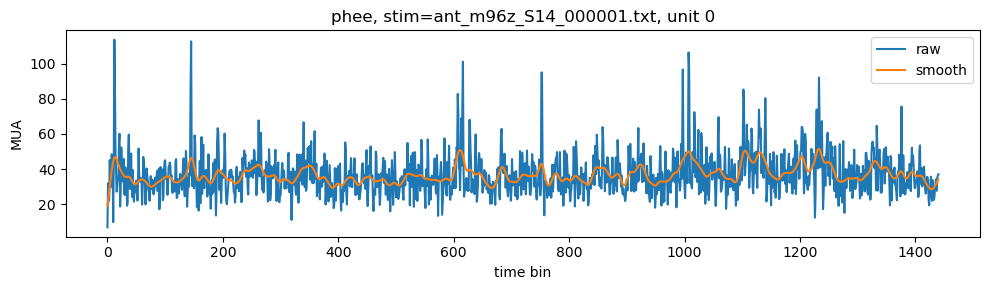

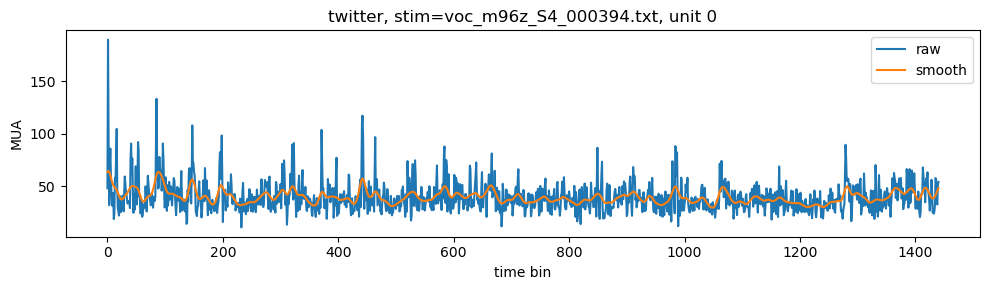

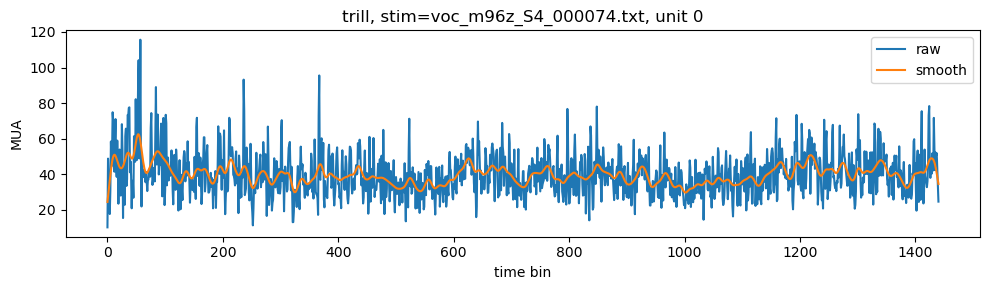

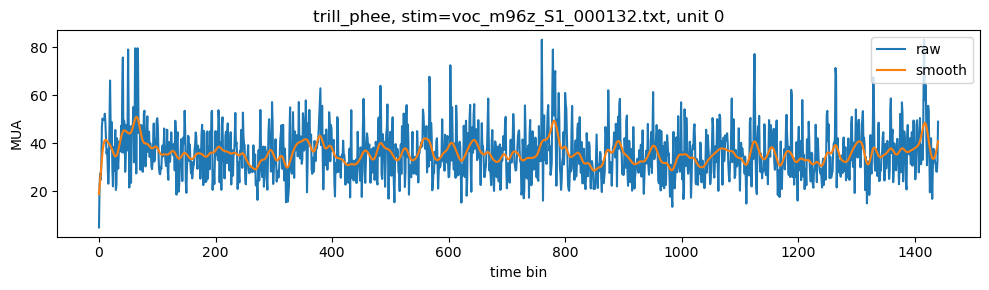

In [13]:
# Diagnostic 3: raw vs smoothed trace overlay

rng = np.random.default_rng(SEED)

for k, name in enumerate(CLASS_NAMES):
    idxs = np.where(y == k)[0]
    idx = rng.choice(idxs)

    plt.figure(figsize=(10, 3))
    plt.plot(X_raw[idx, :, 0], label="raw")
    plt.plot(X_smooth[idx, :, 0], label="smooth")
    plt.title(f"{name}, stim={stim_names[idx]}, unit 0")
    plt.xlabel("time bin")
    plt.ylabel("MUA")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
def save_dataset_npz(name, X_train, X_test, extra=None):
    save_path = OUT_ROOT / f"{name}.npz"

    payload = dict(
        X_train=X_train.astype(np.float32),
        y_train=y[train_mask],
        X_test=X_test.astype(np.float32),
        y_test=y[test_mask],
        class_names=np.asarray(CLASS_NAMES, dtype=object),
        train_stim_names=stim_names[train_mask],
        test_stim_names=stim_names[test_mask],
        train_exp_ids=exp_ids[train_mask],
        test_exp_ids=exp_ids[test_mask],
        smooth_sigma_bins=np.asarray(SMOOTH_SIGMA_BINS),
    )

    if extra is not None:
        payload.update(extra)

    np.savez_compressed(save_path, **payload)

    # Reload immediately to verify the saved file.
    d = np.load(save_path, allow_pickle=True)

    assert d["X_train"].shape == X_train.shape
    assert d["X_test"].shape == X_test.shape
    assert np.array_equal(d["y_train"], y[train_mask])
    assert np.array_equal(d["y_test"], y[test_mask])
    assert list(d["class_names"]) == CLASS_NAMES

    print("saved and verified:", save_path)
    print("  X_train:", X_train.shape)
    print("  X_test :", X_test.shape)

exp_tag = "all" if FOCUS_EXPERIMENTS is None else "_".join(FOCUS_EXPERIMENTS)

save_dataset_npz(
    f"m96z_{exp_tag}_uma_raw",
    X_raw_train,
    X_raw_test,
)

save_dataset_npz(
    f"m96z_{exp_tag}_uma_smooth_sigma{SMOOTH_SIGMA_BINS:g}",
    X_smooth_train,
    X_smooth_test,
)

save_dataset_npz(
    f"m96z_{exp_tag}_uma_smooth_sigma{SMOOTH_SIGMA_BINS:g}_z",
    X_smooth_z_train,
    X_smooth_z_test,
    extra=dict(
        z_mu=z_mu.astype(np.float32),
        z_sd=z_sd.astype(np.float32),
    ),
)

saved and verified: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_raw.npz
  X_train: (160, 1441, 32)
  X_test : (40, 1441, 32)
saved and verified: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_smooth_sigma5.npz
  X_train: (160, 1441, 32)
  X_test : (40, 1441, 32)
saved and verified: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_smooth_sigma5_z.npz
  X_train: (160, 1441, 32)
  X_test : (40, 1441, 32)


In [15]:
print("Prepared UMA datasets:")

for p in sorted(OUT_ROOT.glob("*uma*.npz")):
    d = np.load(p, allow_pickle=True)

    print()
    print(p.name)
    print("  X_train:", d["X_train"].shape)
    print("  y_train:", d["y_train"].shape)
    print("  X_test :", d["X_test"].shape)
    print("  y_test :", d["y_test"].shape)
    print("  classes:", list(d["class_names"]))

    ytr = d["y_train"]
    yte = d["y_test"]
    class_names = list(d["class_names"])

    print("  train counts:")
    for k, name in enumerate(class_names):
        print(f"    {name:12s}", np.sum(ytr == k))

    print("  test counts:")
    for k, name in enumerate(class_names):
        print(f"    {name:12s}", np.sum(yte == k))

Prepared UMA datasets:

m96z_U331_uma_raw.npz
  X_train: (160, 1441, 32)
  y_train: (160,)
  X_test : (40, 1441, 32)
  y_test : (40,)
  classes: ['phee', 'twitter', 'trill', 'trill_phee']
  train counts:
    phee         40
    twitter      40
    trill        40
    trill_phee   40
  test counts:
    phee         10
    twitter      10
    trill        10
    trill_phee   10

m96z_U331_uma_smooth_sigma5.npz
  X_train: (160, 1441, 32)
  y_train: (160,)
  X_test : (40, 1441, 32)
  y_test : (40,)
  classes: ['phee', 'twitter', 'trill', 'trill_phee']
  train counts:
    phee         40
    twitter      40
    trill        40
    trill_phee   40
  test counts:
    phee         10
    twitter      10
    trill        10
    trill_phee   10

m96z_U331_uma_smooth_sigma5_z.npz
  X_train: (160, 1441, 32)
  y_train: (160,)
  X_test : (40, 1441, 32)
  y_test : (40,)
  classes: ['phee', 'twitter', 'trill', 'trill_phee']
  train counts:
    phee         40
    twitter      40
    trill        40
  

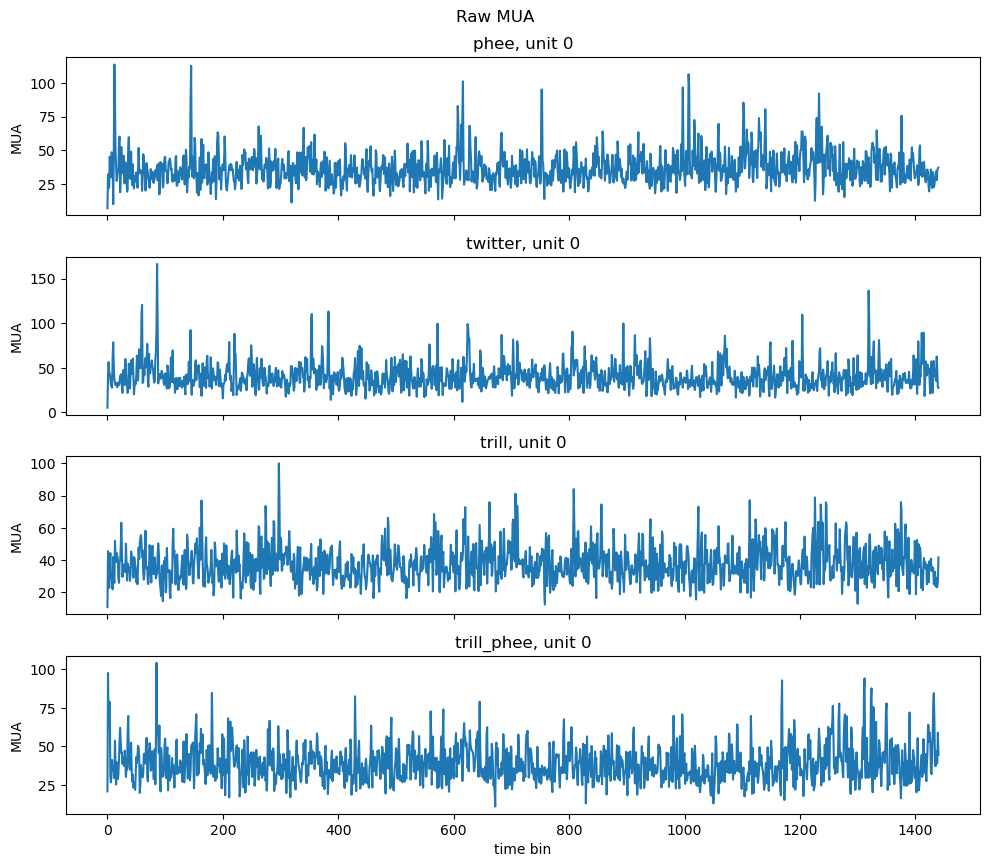

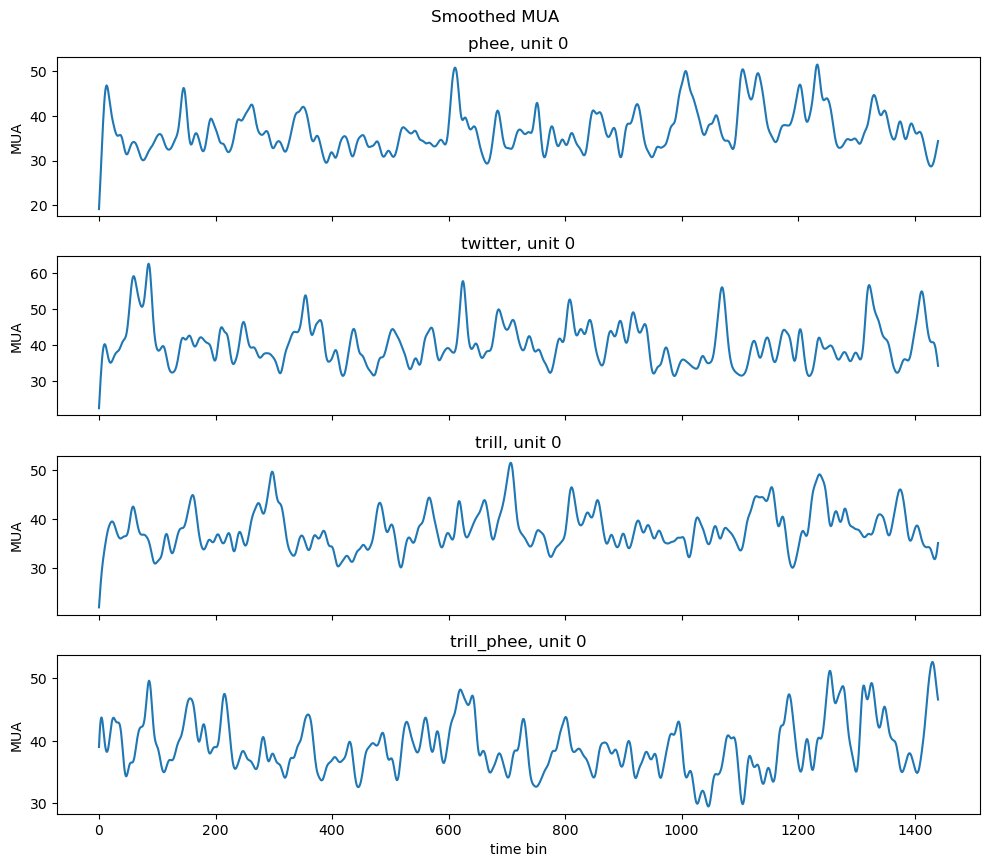

In [16]:
def plot_one_example_per_class(X, title):
    fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(10, 2.2 * len(CLASS_NAMES)), sharex=True)

    if len(CLASS_NAMES) == 1:
        axes = [axes]

    for k, name in enumerate(CLASS_NAMES):
        idx = np.where(y == k)[0][0]
        axes[k].plot(X[idx, :, 0])
        axes[k].set_title(f"{name}, unit 0")
        axes[k].set_ylabel("MUA")

    axes[-1].set_xlabel("time bin")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_one_example_per_class(X_raw, "Raw MUA")
plot_one_example_per_class(X_smooth, "Smoothed MUA")

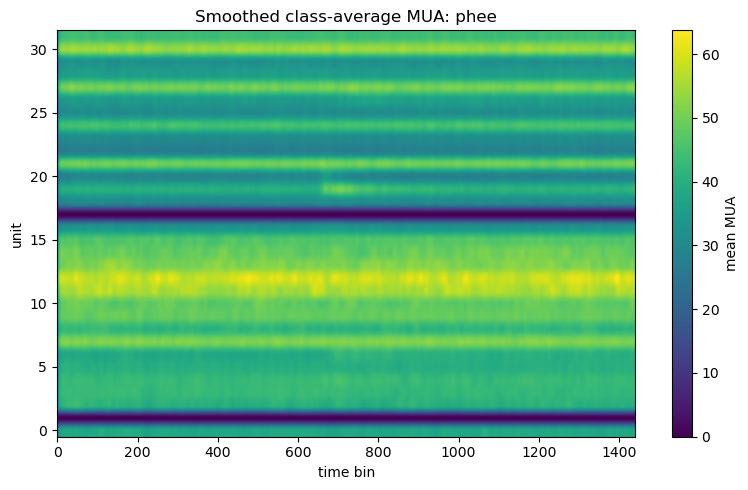

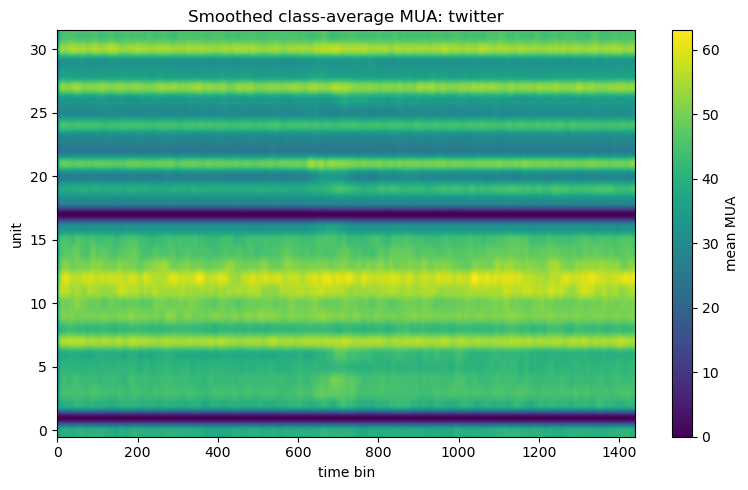

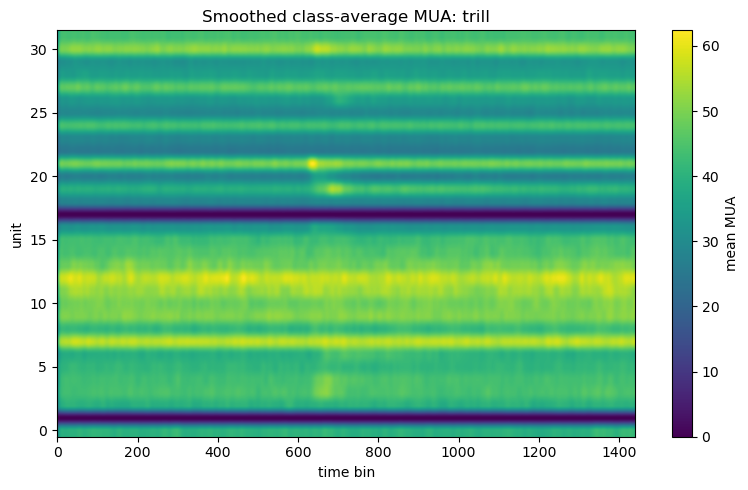

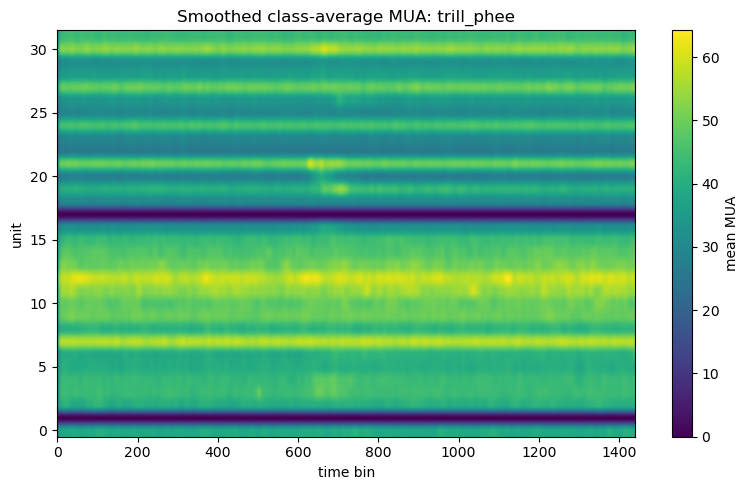

In [17]:
def plot_class_average_heatmaps(X, title):
    for k, name in enumerate(CLASS_NAMES):
        mean_tc = X[y == k].mean(axis=0)  # time x unit

        plt.figure(figsize=(8, 5))
        plt.imshow(mean_tc.T, aspect="auto", origin="lower")
        plt.colorbar(label="mean MUA")
        plt.xlabel("time bin")
        plt.ylabel("unit")
        plt.title(f"{title}: {name}")
        plt.tight_layout()
        plt.show()

plot_class_average_heatmaps(X_smooth, "Smoothed class-average MUA")

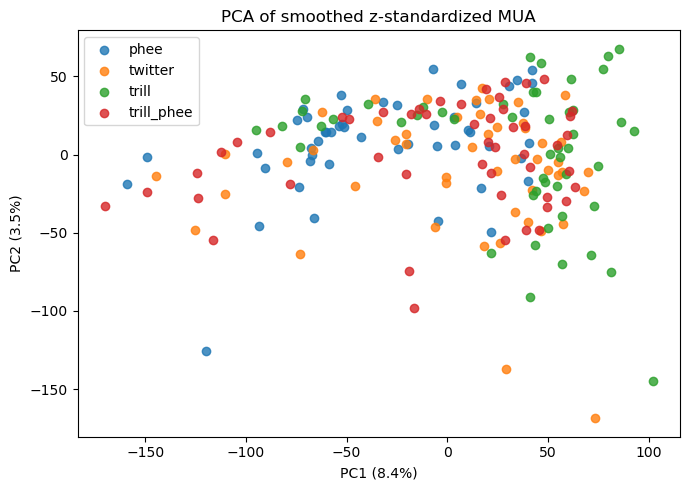

In [18]:
# Optional quick PCA sanity check on smoothed z-scored data

X_all_z = np.zeros_like(X_smooth, dtype=np.float32)
X_all_z[train_mask] = X_smooth_z_train
X_all_z[test_mask] = X_smooth_z_test

X_flat = X_all_z.reshape(X_all_z.shape[0], -1)
X_flat = X_flat - X_flat.mean(axis=0, keepdims=True)

U, S, Vt = np.linalg.svd(X_flat, full_matrices=False)
Z2 = U[:, :2] * S[:2]

explained = S**2 / np.sum(S**2)

plt.figure(figsize=(7, 5))

for k, name in enumerate(CLASS_NAMES):
    mask = y == k
    plt.scatter(Z2[mask, 0], Z2[mask, 1], label=name, alpha=0.8)

plt.xlabel(f"PC1 ({explained[0]:.1%})")
plt.ylabel(f"PC2 ({explained[1]:.1%})")
plt.title("PCA of smoothed z-standardized MUA")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
def write_uea_ts(path, X, y_vec, class_names, problem_name):
    n, T, D = X.shape

    with open(path, "w") as f:
        f.write(f"@problemName {problem_name}\n")
        f.write("@timeStamps false\n")
        f.write("@missing false\n")
        f.write("@univariate false\n")
        f.write(f"@dimensions {D}\n")
        f.write("@equalLength true\n")
        f.write(f"@seriesLength {T}\n")
        f.write("@classLabel true " + " ".join(class_names) + "\n")
        f.write("@data\n")

        for i in range(n):
            dims = []
            for d in range(D):
                vals = ",".join(f"{v:.6g}" for v in X[i, :, d])
                dims.append(vals)

            label = class_names[int(y_vec[i])]
            f.write(":".join(dims) + ":" + label + "\n")

def export_ts_dataset(name, X_train, X_test):
    ts_dir = OUT_ROOT / name
    ts_dir.mkdir(exist_ok=True)

    train_path = ts_dir / f"{name}_TRAIN.ts"
    test_path = ts_dir / f"{name}_TEST.ts"

    write_uea_ts(train_path, X_train, y[train_mask], CLASS_NAMES, name)
    write_uea_ts(test_path, X_test, y[test_mask], CLASS_NAMES, name)

    print("saved:", train_path)
    print("saved:", test_path)

export_ts_dataset(
    f"m96z_{exp_tag}_uma_raw",
    X_raw_train,
    X_raw_test,
)

export_ts_dataset(
    f"m96z_{exp_tag}_uma_smooth_sigma{SMOOTH_SIGMA_BINS:g}",
    X_smooth_train,
    X_smooth_test,
)

export_ts_dataset(
    f"m96z_{exp_tag}_uma_smooth_sigma{SMOOTH_SIGMA_BINS:g}_z",
    X_smooth_z_train,
    X_smooth_z_test,
)

saved: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_raw/m96z_U331_uma_raw_TRAIN.ts
saved: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_raw/m96z_U331_uma_raw_TEST.ts
saved: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_smooth_sigma5/m96z_U331_uma_smooth_sigma5_TRAIN.ts
saved: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_smooth_sigma5/m96z_U331_uma_smooth_sigma5_TEST.ts
saved: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_smooth_sigma5_z/m96z_U331_uma_smooth_sigma5_z_TRAIN.ts
saved: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_smooth_sigma5_z/m96z_U331_uma_smooth_sigma5_z_TEST.ts
